In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.integrate import solve_ivp

In [3]:
# Physical Parameters

m = 1.0         # kg, body mass
L = 0.5         # m, distance from axle / pivot point to center of mass
g = 9.81        # m/s^2, gravity
b = 0.05        # N*m*s/rad, damping coefficient

I = m * L**2    # moment of ineratia

In [ ]:
# Control Input - i.e. what torque should the wheel/motor apply right now?

def control_input(t, theta, omega):
    """
    Takes as input
        current time t
        current body angle theta
        current angular velocity omega
    Equivalent wheel / body torque in N*m
    For now, no control
    """

    tau = 0.0
    return tau

In [ ]:
# Dynamics model - given the current angle, angular 
# velocity and motor torque, how does the pendulum move next
# this only describes the physics at one instance (for specific parameters)
# the simulation is done later by solve_ivp

# Theta is the angle
# Angular velocity (i.e. how the angle changes) is omega (= theta_dot)
# Angular acceleration (i.e. how fast the angle changes) is omega_dot (or theta_dotdot)

# state should be a list or array of theta and omega

def pendulum_dynamics(t, state):

    theta, omega = state

    # Call the controler
    tau = control_input(t, theta, omega)

    theta_dot = omega
    omega_dot = (m * g * L * np.sin(theta) - b * omega * tau) / I

    # returns rate of change
    return [theta_dot, omega_dot]


In [8]:
# Initial conditions

theta0 = np.deg2rad(5) # Initial tile = 5 degrees
omega0 = 0.0            # Initially the pendulum is still - angular velocity = 0

initial_state = [theta0, omega0]

# Simulate from 0 to 5 seconds
t_start = 0.0
t_end = 5.0

In [18]:
# Simulate

# solve_ivp -> solve initial value problem - i.e. I know where the system starts
# now compute where it goes

# Essentially this does:
# At t = 0:
#    state = [theta, omega]
#
# Ask pendulum_dynamics:
#    how fast are theta and omega changing?
#
# Use that information to estimate:
#    state a little later
#
# Repeat many times.

# Basically solve_ivp does:
#
# theta = theta0
# omega = omega0
# 
# for step in range(500):
#     theta_dot = omega
#     omega_dot = (m * g * L * np.sin(theta) - b * omega + tau) / I
# 
#     theta = theta + theta_dot * dt
#     omega = omega + omega_dot * dt

# This is euler integration
# It says: new value = old value + rate of change * time step

dt = 0.01

solution = solve_ivp(
    fun = pendulum_dynamics,    # our function that describes the pendulum's physics
    t_span = [t_start, t_end],  # simulate from 0 to 5 seconds
    y0 = initial_state,         # starting angle and angular velocity
    max_step = dt             # do not take steps larger than 0.01 seconds
)

print(solution)

# Extract results

t = solution.t
theta = solution.y[0]
omega = solution.y[1]

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.782e-04 ...  4.996e+00  5.000e+00]
        y: [[ 8.727e-02  8.727e-02 ...  2.235e+00  2.264e+00]
            [ 0.000e+00  9.887e-04 ...  7.955e+00  8.011e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 3014
     njev: 0
      nlu: 0


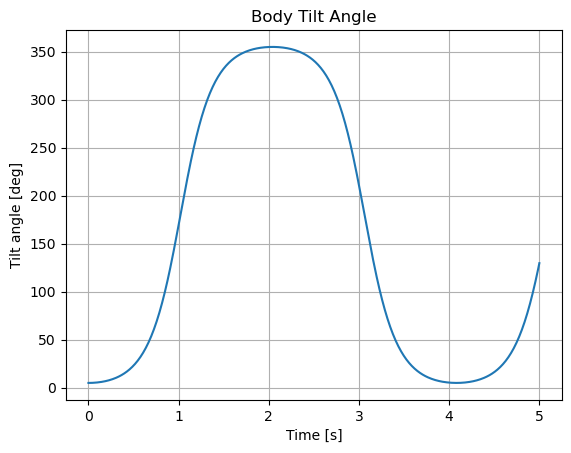

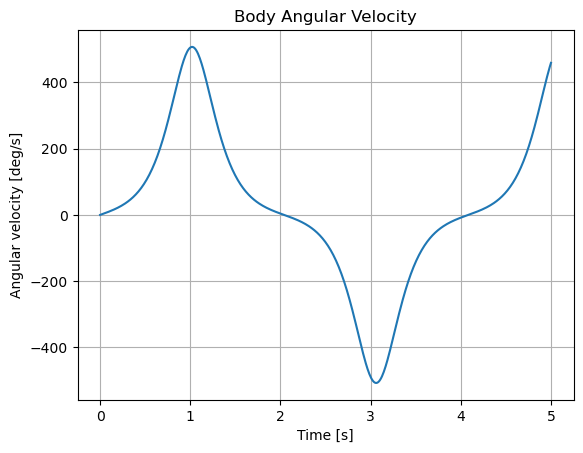

In [ ]:
# Plot results

# Plot the angle
plt.figure()
plt.plot(t, np.rad2deg(theta))
plt.xlabel("Time [s]")
plt.ylabel("Tilt angle [deg]")
plt.title("Body Tilt Angle")
plt.grid(True)

# Plot angular velocity
plt.figure()
plt.plot(t, np.rad2deg(omega))
plt.xlabel("Time [s]")
plt.ylabel("Angular velocity [deg/s]")
plt.title("Body Angular Velocity")
plt.grid(True)